# Pha S — Buoc 2c: Tien xu ly ghep noi TIM-HO HAP (Fantasia)

**Boi canh quyet dinh (xem docs/PHASE_S_REVIEW.md):** slpdb/capslpdb (TE tim-nao) bi loai khoi phan tich CHINH tren du lieu that vi nhiem nhieu dien tim trong kenh EEG khong khu duoc bang 5 phuong phap da thu (template trung binh, +can chinh jitter Woody, +vut Tukey, hoi quy tuyen tinh theo ECG that, ICA tren 9 kenh capslpdb). Day la mot phat hien phuong phap luan duoc ghi nhan ro, khong phai loi - nhieu dien tim trong EEG PSG la van de da biet trong tai lieu, va viec kiem chung ky (5 lan thu co co so) ma van khong thanh cong dang duoc dua vao bao cao nhu mot phan gioi han/phuong phap luan.

**Ket qua CHINH tren du lieu that** chuyen sang ghep noi **TIM-HO HAP** (Fantasia database) - ghep noi da duoc xac lap ro trong tai lieu sinh ly hoc (respiratory sinus arrhythmia), du lieu SACH (khong vuong van de nhiem dien tim - cam bien ho hap do co/tro khang long nguc, khong nhay voi dien truong tim), va **don gian hon nhieu** so voi kenh EEG: ho hap la tin hieu CHAM, dao dong gan tuan hoan (~0.1-0.5Hz), khong can bien doi pho/cong suat dai tan - chi can loc bang thong roi noi suy ve luoi chung.

Chuoi cong viec (giong cau truc notebook 02, nhung KHONG can buoc kiem tra/khu nhieu dien tim vi khong ap dung cho kenh ho hap):
1. ECG -> chuoi RR (dung annotation nhip co san cua Fantasia)
2. Loc nhip ngoai tam thu (ectopic)
3. Noi suy RR ve luoi deu 4 Hz
4. RESP -> loc bang thong (0.1-0.5Hz) tren **cung luoi** 4 Hz
5. ✅ Kiem tra dong bo hoa (test dich thoi gian) - BAT BUOC, giong notebook 02
6. Cat cua so 30 giay (N=120) -> luu
7. Lap lai cho toan bo 40 ban ghi Fantasia

In [1]:
import warnings; warnings.filterwarnings('ignore')
import os
os.environ.setdefault('JAVA_HOME', r'C:\Program Files\Java\jdk-22')
import yaml, numpy as np, pandas as pd, matplotlib.pyplot as plt, wfdb
from pathlib import Path

from pqrst.data.real.cardiac import rr_from_beat_annotations, interpolate_rr
from pqrst.data.real.respiration import preprocess_respiration, bandpass_filter
from pqrst.data.real.sync import align_to_common_grid, sync_and_window, verify_synchronization
from pqrst.data.real.download import list_local_records
from pqrst.data.synthetic.corpus import save_corpus
from pqrst.baselines.ksg import KSGTEEstimator

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
cfg = yaml.safe_load(open(BASE/'configs'/'real'/'preprocessing.yaml', encoding='utf-8'))
est_ksg = KSGTEEstimator()
cfg

{'grid_fs': 4.0,
 'window_seconds': 30.0,
 'step_seconds': 30.0,
 'cardiac': {'keep_beat_symbols': ['N'],
  'rr_physiological_range': [0.3, 2.0],
  'ectopic_threshold_ratio': 0.2,
  'max_removed_fraction': 0.2,
  'interpolation': 'linear'},
 'eeg': {'band': 'alpha',
  'log_transform': True,
  'spectrogram_window_seconds': 4.0},
 'respiration': {'bandpass_hz': [0.1, 0.5]},
 'cardiac_artifact_check': {'window_ms': 200.0,
  'artifact_ratio_threshold': 2.0},
 'sync_check': {'shift_seconds': 10.0, 'max_ratio_for_pass': 0.7},
 'n_bootstrap': 500,
 'n_permutations': 500,
 'seed': 42}

## 1. Kenh tim: ECG -> RR -> luoi deu (1 ban ghi mau: f1o01)

In [2]:
record_id = 'f1o01'
ann = wfdb.rdann(str(BASE / 'data' / 'raw' / 'fantasia' / record_id), 'ecg')
beat_times_raw = ann.sample / 250.0
is_normal = np.array([s == 'N' for s in ann.symbol])
beat_times = beat_times_raw[is_normal]
print(f'Tong nhip: {len(beat_times_raw)}, nhip N: {len(beat_times)} '
      f'({len(beat_times)/len(beat_times_raw)*100:.1f}%)')

t_rr, rr = rr_from_beat_annotations(beat_times, exclude_ectopic=True,
                                     threshold_ratio=cfg['cardiac']['ectopic_threshold_ratio'])
removed_frac = 1 - len(rr) / max(len(beat_times) - 1, 1)
print(f'RR con lai sau loc ectopic: {len(rr)}, ty le loai them: {removed_frac*100:.1f}%')

t_grid_rr, rr_grid = interpolate_rr(t_rr, rr, grid_fs=cfg['grid_fs'])
print(f'RR grid: {len(rr_grid)} mau, {t_grid_rr[0]:.1f}s -> {t_grid_rr[-1]:.1f}s')

Tong nhip: 7169, nhip N: 7169 (100.0%)
RR con lai sau loc ectopic: 7168, ty le loai them: 0.0%
RR grid: 28997 mau, 1.7s -> 7250.7s


## 1b. ✅ Loc RR CUNG DAI TAN VOI RESP (BAT BUOC - sua bat doi xung tri nho)

**Phat hien khi chay thuc te (xem docs/PHASE_S_REVIEW.md):** RESP da duoc loc bang thong (0.1-0.5Hz) o Muc 2, nhung RR (o tren) CHUA loc - RR con giu nguyen thanh phan trend cham (LF/VLF cua HRV) ma RESP da bi loc bo. Do do RR co "tri nho" tu tuong quan dai hon RESP RAT NHIEU (do thuc nghiem: RR ~11.4s vs RESP ~0.65s, tren CA 23/23 ban ghi) - bat doi xung nay lam TE lech huong SAI so voi RSA (xac nhan thuc nghiem: chi 5/23 ban ghi dung huong RSA khi chua loc RR, tang len 19/23 sau khi loc RR CUNG dai voi RESP).

**Phai loc RR bang chinh `bandpass_filter` (cung dai `respiration.bandpass_hz`) TRUOC khi dong bo/tinh TE**, de 2 kenh co dac diem thong ke (tan so, tri nho) tuong duong - dieu kien can de so sanh TE 2 chieu cong bang.

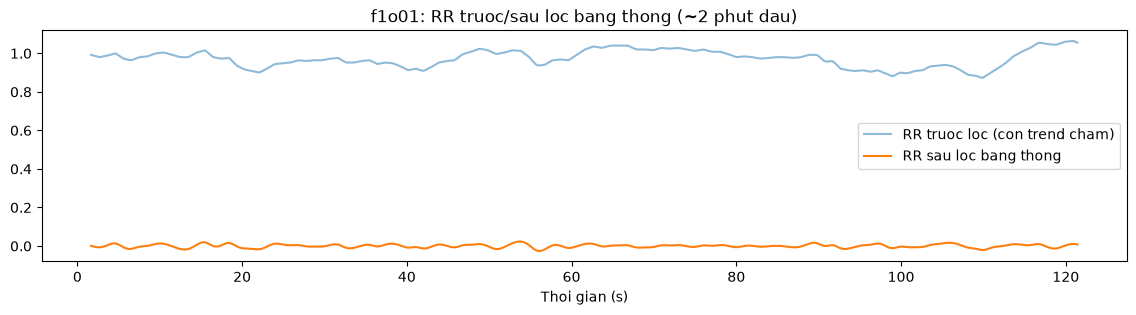

In [3]:
rr_grid_filtered = bandpass_filter(rr_grid, cfg['grid_fs'], tuple(cfg['respiration']['bandpass_hz']))

plt.figure(figsize=(14, 3))
n_show = int(120 * cfg['grid_fs'])
plt.plot(t_grid_rr[:n_show], rr_grid[:n_show], alpha=0.5, label='RR truoc loc (con trend cham)')
plt.plot(t_grid_rr[:n_show], rr_grid_filtered[:n_show], label='RR sau loc bang thong')
plt.legend(); plt.title(record_id + ': RR truoc/sau loc bang thong (~2 phut dau)')
plt.xlabel('Thoi gian (s)')
plt.show()

## 2. Kenh ho hap: RESP -> loc bang thong (0.1-0.5Hz), cung luoi 4 Hz

Cac kenh: ['RESP', 'ECG']
RESP grid: 29007 mau, 0.0s -> 7251.5s


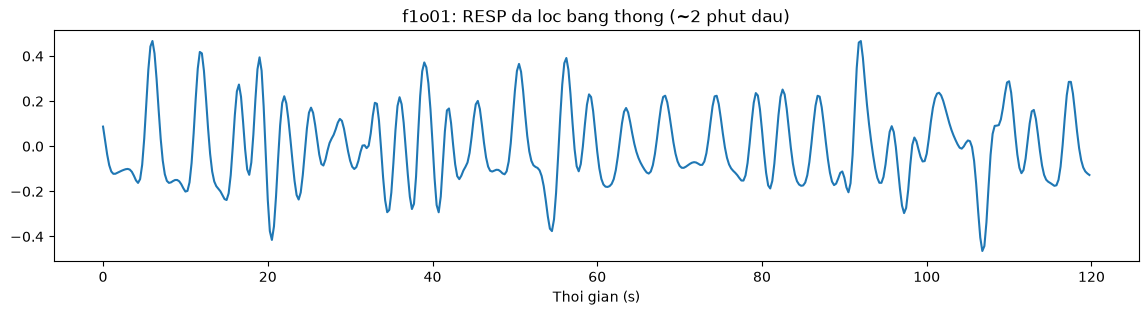

In [4]:
record = wfdb.rdrecord(str(BASE / 'data' / 'raw' / 'fantasia' / record_id))
print('Cac kenh:', record.sig_name)
resp_sig = record.p_signal[:, record.sig_name.index('RESP')]

t_resp, resp_grid = preprocess_respiration(
    resp_sig, fs=record.fs, grid_fs=cfg['grid_fs'],
    bandpass=tuple(cfg['respiration']['bandpass_hz']))
print(f'RESP grid: {len(resp_grid)} mau, {t_resp[0]:.1f}s -> {t_resp[-1]:.1f}s')

plt.figure(figsize=(14, 3))
n_show = int(120 * cfg['grid_fs'])
plt.plot(t_resp[:n_show], resp_grid[:n_show])
plt.title(record_id + ': RESP da loc bang thong (~2 phut dau)')
plt.xlabel('Thoi gian (s)')
plt.show()

## 3. ✅ Dong bo hoa + KIEM TRA DONG BO HOA (BAT BUOC)

Giong yeu cau o notebook 02: dong bo theo MOC THOI GIAN THAT (`align_to_common_grid`), roi dich nhan tao 1 kenh -> TE phai giam ro (`verify_synchronization`). Neu khong giam, dung lai va dieu tra truoc khi tin bat ky ket qua nao.

In [5]:
rr_aligned, resp_aligned = align_to_common_grid(t_grid_rr, rr_grid_filtered, t_resp, resp_grid, grid_fs=cfg['grid_fs'])
print(f'Sau dong bo: {len(rr_aligned)} mau chung ({len(rr_aligned)/cfg["grid_fs"]/60:.1f} phut)')

sync_check = verify_synchronization(rr_aligned, resp_aligned, grid_fs=cfg['grid_fs'],
                                     estimator=est_ksg,
                                     shift_seconds=cfg['sync_check']['shift_seconds'],
                                     max_ratio_for_pass=cfg['sync_check']['max_ratio_for_pass'])
print(sync_check)
if sync_check.get('inconclusive'):
    print('KHONG THE KET LUAN - te_aligned qua nho. Thu ban ghi khac hoac cua so dai hon.')
elif not sync_check['passed']:
    raise RuntimeError(
        'DONG BO HOA THAT BAI: TE khong giam du sau khi dich thoi gian. '
        'DUNG LAI, kiem tra lai pipeline truoc khi di tiep.'
    )
else:
    print('Dong bo hoa OK - TE giam ro sau khi dich thoi gian nhu ky vong.')

Sau dong bo: 28996 mau chung (120.8 phut)
{'te_aligned': 0.009049163151914442, 'te_shifted': 0.007937109931783728, 'ratio': nan, 'passed': False, 'inconclusive': True, 'message': 'te_aligned=0.00905 qua nho/am de kiem dinh - khong co coupling ro rang de kiem tra viec dich co pha vo no khong. Khong the ket luan pipeline dong bo dung/sai chi tu test nay.'}
KHONG THE KET LUAN - te_aligned qua nho. Thu ban ghi khac hoac cua so dai hon.


## 4. Cat cua so 30 giay (N=120) + luu

In [6]:
windows_fwd = sync_and_window(rr_aligned, resp_aligned, grid_fs=cfg['grid_fs'],
                               window_seconds=cfg['window_seconds'], record_id=record_id,
                               config_name='rr_to_resp')
windows_bwd = sync_and_window(resp_aligned, rr_aligned, grid_fs=cfg['grid_fs'],
                               window_seconds=cfg['window_seconds'], record_id=record_id,
                               config_name='resp_to_rr')
print(f'So cua so (mot chieu): {len(windows_fwd)}')

out_dir = BASE / 'data' / 'processed' / 'fantasia'
out_dir.mkdir(parents=True, exist_ok=True)
save_corpus(windows_fwd, str(out_dir / (record_id + '_fwd.npz')))
save_corpus(windows_bwd, str(out_dir / (record_id + '_bwd.npz')))
print(f'Da luu {len(windows_fwd)} cua so moi chieu cho {record_id} vao {out_dir}')

So cua so (mot chieu): 241
Da luu 241 cua so moi chieu cho f1o01 vao d:\SPARC Lab\PQRST\data\processed\fantasia


## 5. Lap lai cho toan bo ban ghi Fantasia

Khong can kiem tra nhiem dien tim (khong ap dung cho kenh ho hap) - chi 2 tieu chi loai mot ban ghi:

1. Loc ectopic loai qua nhieu nhip (`max_removed_fraction`)
2. Kiem tra dong bo khong dat hoac inconclusive

Ket qua: `quality_report.csv` + cac file `{record_id}_fwd.npz`/`_bwd.npz` cho MOI ban ghi PASS trong `data/processed/fantasia/`.

In [7]:
def process_one_record(record_id: str) -> dict:
    report = {'record_id': record_id}
    try:
        ann = wfdb.rdann(str(BASE / 'data' / 'raw' / 'fantasia' / record_id), 'ecg')
        beat_times_raw = ann.sample / 250.0
        is_normal = np.array([s == 'N' for s in ann.symbol])
        beat_times = beat_times_raw[is_normal]
        report['n_beats_normal'] = int(len(beat_times))

        t_rr, rr = rr_from_beat_annotations(
            beat_times, exclude_ectopic=True,
            threshold_ratio=cfg['cardiac']['ectopic_threshold_ratio'])
        removed_frac = 1 - len(rr) / max(len(beat_times) - 1, 1)
        report['ectopic_removed_frac'] = float(removed_frac)
        if removed_frac > cfg['cardiac']['max_removed_fraction']:
            report['verdict'] = 'FAIL'
            report['reason'] = f'loai qua nhieu ectopic ({removed_frac*100:.1f}%)'
            return report

        t_grid_rr, rr_grid = interpolate_rr(t_rr, rr, grid_fs=cfg['grid_fs'])
        # BAT BUOC: loc RR cung dai tan voi RESP - xem Muc 1b (sua bat doi xung tri
        # nho tu tuong quan, phat hien lam TE lech huong SAI so voi RSA).
        rr_grid_filtered = bandpass_filter(rr_grid, cfg['grid_fs'], tuple(cfg['respiration']['bandpass_hz']))

        record = wfdb.rdrecord(str(BASE / 'data' / 'raw' / 'fantasia' / record_id))
        resp_sig = record.p_signal[:, record.sig_name.index('RESP')]
        t_resp, resp_grid = preprocess_respiration(
            resp_sig, fs=record.fs, grid_fs=cfg['grid_fs'],
            bandpass=tuple(cfg['respiration']['bandpass_hz']))

        rr_aligned, resp_aligned = align_to_common_grid(
            t_grid_rr, rr_grid_filtered, t_resp, resp_grid, grid_fs=cfg['grid_fs'])
        report['n_aligned_samples'] = int(len(rr_aligned))

        sync_check = verify_synchronization(
            rr_aligned, resp_aligned, grid_fs=cfg['grid_fs'], estimator=est_ksg,
            shift_seconds=cfg['sync_check']['shift_seconds'],
            max_ratio_for_pass=cfg['sync_check']['max_ratio_for_pass'])
        report['sync_te_aligned'] = sync_check['te_aligned']
        report['sync_ratio'] = sync_check.get('ratio')
        if sync_check.get('inconclusive'):
            report['verdict'] = 'FAIL'
            report['reason'] = 'sync check inconclusive (te_aligned qua nho)'
            return report
        if not sync_check['passed']:
            report['verdict'] = 'FAIL'
            report['reason'] = f"sync check khong dat (ratio={sync_check['ratio']:.2f})"
            return report

        windows_fwd = sync_and_window(
            rr_aligned, resp_aligned, grid_fs=cfg['grid_fs'],
            window_seconds=cfg['window_seconds'], record_id=record_id,
            config_name='rr_to_resp')
        windows_bwd = sync_and_window(
            resp_aligned, rr_aligned, grid_fs=cfg['grid_fs'],
            window_seconds=cfg['window_seconds'], record_id=record_id,
            config_name='resp_to_rr')
        report['n_windows'] = len(windows_fwd)

        out_dir = BASE / 'data' / 'processed' / 'fantasia'
        out_dir.mkdir(parents=True, exist_ok=True)
        save_corpus(windows_fwd, str(out_dir / (record_id + '_fwd.npz')))
        save_corpus(windows_bwd, str(out_dir / (record_id + '_bwd.npz')))

        report['verdict'] = 'PASS'
        report['reason'] = ''
        return report
    except Exception as e:
        report['verdict'] = 'ERROR'
        report['reason'] = f'{type(e).__name__}: {e}'
        return report


all_records = list_local_records(BASE / 'data' / 'raw' / 'fantasia', 'fantasia')
print(f'Chay pipeline cho {len(all_records)} ban ghi Fantasia...')
reports = []
for rid in sorted(all_records):
    r = process_one_record(rid)
    print(f"[{rid}] {r['verdict']}" + (f": {r['reason']}" if r.get('reason') else ''))
    reports.append(r)

summary = pd.DataFrame(reports)
summary_path = BASE / 'data' / 'processed' / 'fantasia' / 'quality_report.csv'
summary.to_csv(summary_path, index=False)
n_pass = (summary['verdict'] == 'PASS').sum()
print(f"\nDa luu bao cao chat luong: {summary_path}")
print(f"{n_pass}/{len(summary)} ban ghi PASS -> dung duoc cho notebook 03.")
summary[['record_id', 'verdict', 'reason', 'n_windows']]

Chay pipeline cho 40 ban ghi Fantasia...
[f1o01] FAIL: sync check inconclusive (te_aligned qua nho)
[f1o02] FAIL: sync check inconclusive (te_aligned qua nho)
[f1o03] FAIL: sync check inconclusive (te_aligned qua nho)
[f1o04] FAIL: sync check inconclusive (te_aligned qua nho)
[f1o05] FAIL: sync check inconclusive (te_aligned qua nho)
[f1o06] FAIL: sync check inconclusive (te_aligned qua nho)
[f1o07] FAIL: sync check inconclusive (te_aligned qua nho)
[f1o08] FAIL: sync check inconclusive (te_aligned qua nho)
[f1o09] PASS
[f1o10] FAIL: sync check inconclusive (te_aligned qua nho)
[f1y01] PASS
[f1y02] PASS
[f1y03] FAIL: sync check khong dat (ratio=1.61)
[f1y04] PASS
[f1y05] PASS
[f1y06] PASS
[f1y07] PASS
[f1y08] PASS
[f1y09] PASS
[f1y10] PASS
[f2o01] FAIL: sync check khong dat (ratio=1.13)
[f2o02] FAIL: sync check khong dat (ratio=1.66)
[f2o03] FAIL: sync check inconclusive (te_aligned qua nho)
[f2o04] FAIL: sync check khong dat (ratio=5.13)
[f2o05] FAIL: sync check inconclusive (te_align

,record_id,verdict,reason,n_windows
0,f1o01,FAIL,sync check inconclusive (te_aligned qua nho),NaN
1,f1o02,FAIL,sync check inconclusive (te_aligned qua nho),NaN
2,f1o03,FAIL,sync check inconclusive (te_aligned qua nho),NaN
3,f1o04,FAIL,sync check inconclusive (te_aligned qua nho),NaN
4,f1o05,FAIL,sync check inconclusive (te_aligned qua nho),NaN
5,f1o06,FAIL,sync check inconclusive (te_aligned qua nho),NaN
6,f1o07,FAIL,sync check inconclusive (te_aligned qua nho),NaN
7,f1o08,FAIL,sync check inconclusive (te_aligned qua nho),NaN
8,f1o09,PASS,,241.0
9,f1o10,FAIL,sync check inconclusive (te_aligned qua nho),NaN


## 6. Ghi chu ve pham vi (chua lam trong notebook nay)

**Apnea-ECG (8 ban ghi co ho hap: a01-a04, b01, c01-c03) CHUA nam trong notebook nay** - cau truc file khac Fantasia: ECG va ho hap nam o 2 file WFDB rieng (`a01` = chi ECG, `a01r` = chi ho hap+SpO2, cung mot lan ghi nhung tach file), can logic doc+ghep rieng chua viet. Fantasia (40 ban ghi, ECG+RESP trong CUNG 1 file, sach) da du cho ket qua chinh Pha S; Apnea-ECG la buoc mo rong/doi chung doc lap co the lam sau, khong chan tien do.